In [ ]:
# notebook to showcase conversion from SurfaceArrhenius to SurfaceBlowersMasel

In [42]:
import os
import matplotlib.pyplot as plt
import numpy as np
import cantera as ct
import rmgpy.chemkin
import copy

%matplotlib inline

In [82]:
def plot_kinetics(rxns, labels=None):
    """Function for plotting reaction kinetics
    Takes in a list of RMG reactions (rmgpy.reaction.Reaction) or a single reaction
    """
    plt.xlabel('1000 / T (K^-1)')
    plt.ylabel('log10(k)')
    linestyles = ['solid', 'dashed', 'dotted']
    if type(rxns) != list:
        rxns = [rxns]
    T = np.linspace(300, 3000, 1001)
    for m, rxn in enumerate(rxns):
        k = np.zeros(len(T))
        for i in range(0, len(T)):
            if hasattr(rxn, 'kinetics') and isinstance(rxn.kinetics, rmgpy.kinetics.arrhenius.ArrheniusBM):
                k[i] = rxn.kinetics.get_rate_coefficient(T[i], dHrxn=rxn.get_enthalpy_of_reaction(T[i]))
            else:
                k[i] = rxn.get_rate_coefficient(T[i], 101325)
        plt.plot(1000.0 / T, np.log10(k), linestyle=linestyles[m % len(linestyles)])
    if labels:
        plt.legend(labels)
    plt.show()

In [3]:
database = rmgpy.data.rmg.RMGDatabase()
database.load(
    path = rmgpy.settings['database.directory'],
    thermo_libraries = ['Klippenstein_Glarborg2016', 'BurkeH2O2', 'thermo_DFT_CCSDTF12_BAC',  # these libraries from BM fitting script
                        'DFT_QCI_thermo', 'primaryThermoLibrary', 'primaryNS', 'NitrogenCurran', 'NOx2018', 'FFCM1(-)',
                        'SulfurLibrary', 'SulfurGlarborgH2S','SABIC_aromatics'],
    reaction_libraries = ['C3'],
    kinetics_families = [],
    kinetics_depositories = ['training'],
    depository = False,
) 

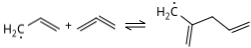

In [61]:
# pick a kinetics object and make a Blowers-Masel version

# Fill in the thermo for each entry so we can compute 
entry_label = 1
my_reaction = rmgpy.reaction.Reaction()
my_reaction.reactants = database.kinetics.libraries['C3'].entries[1].item.reactants
for i in range(len(my_reaction.reactants)):
    my_reaction.reactants[i].thermo = database.thermo.get_thermo_data(my_reaction.reactants[i])

my_reaction.products = database.kinetics.libraries['C3'].entries[1].item.products
for i in range(len(my_reaction.products)):
    my_reaction.products[i].thermo = database.thermo.get_thermo_data(my_reaction.products[i])


my_reaction.kinetics = database.kinetics.libraries['C3'].entries[1].data
display(my_reaction)





In [78]:
bm_reaction = copy.deepcopy(my_reaction)
bm_reaction.kinetics = rmgpy.kinetics.arrhenius.ArrheniusBM().fit_to_reactions([my_reaction], w0=1e6)

In [79]:
my_reaction.to_cantera()

C3H4a + aC3H5 <=> prod_1    <Reaction(Arrhenius)>

In [80]:
bm_reaction.to_cantera()

NotImplementedError: Unable to set cantera kinetics for ArrheniusBM(A=(4.2e-05,'m^3/(mol*s)'), n=3.27, w0=(1e+06,'J/mol'), E0=(101893,'J/mol'), comment="""Fitted to 1 reaction.""")

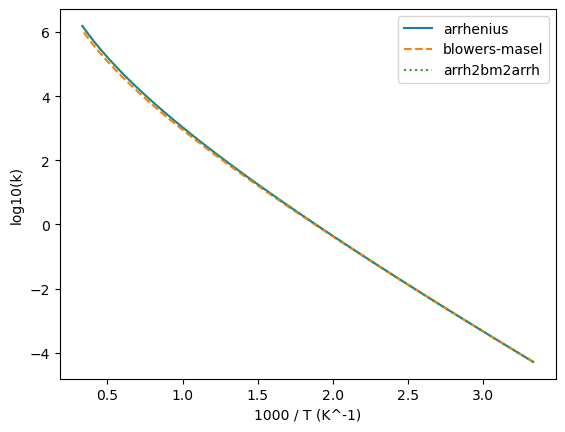

In [83]:
plot_kinetics([
    my_reaction,
    bm_reaction,
    bm_reaction.kinetics.to_arrhenius(my_reaction.get_enthalpy_of_reaction(298))
], ['arrhenius', 'blowers-masel', 'arrh2bm2arrh'])